# The pitch logic — why this package, step by step

## Where the assignment is answered

| Original ask | Answered in |
|---|---|
| Part 1 — the mechanism: what the barrier is, and why the premium persists | [00 pitch](00_executive_pitch.ipynb), [02 anatomy](02_premium_anatomy.ipynb); panels P1, P2 |
| Part 2 — the trade: convergence RV, its dynamics and its economics | [04 regimes](04_regimes_convergence.ipynb), [06 ledger](06_complexity_ledger.ipynb); panels P3, P7, P8, P8b |
| Part 3 — execution: access, financing, capital, capacity, exits | panels P2, P4a, P4b, P5, P9; trade sheets in `pipeline/hedging/sheets.py` |
| Macro and FX risk | [07 environment](07_macro_environment.ipynb); panels P0a, P0b |

**What the pitch sells is a package, not a view** — and that is a conclusion the repo earned
rather than assumed. Directional timing was tested against an overparameterised alternative
(notebook 06) and the shallow model won, but only gross, pre-cost, on the comparator panel with
SKHY never fitted. So the honest product is access, financing and capital efficiency.

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from pipeline.viz import theme
from scripts.export_client_pack import panels
from scripts.build_deck_v2 import extra_panels
theme.apply()
PANELS = dict(panels()) | dict(extra_panels())

## 1. The chain

Six steps. Each answers the objection the previous one raises.

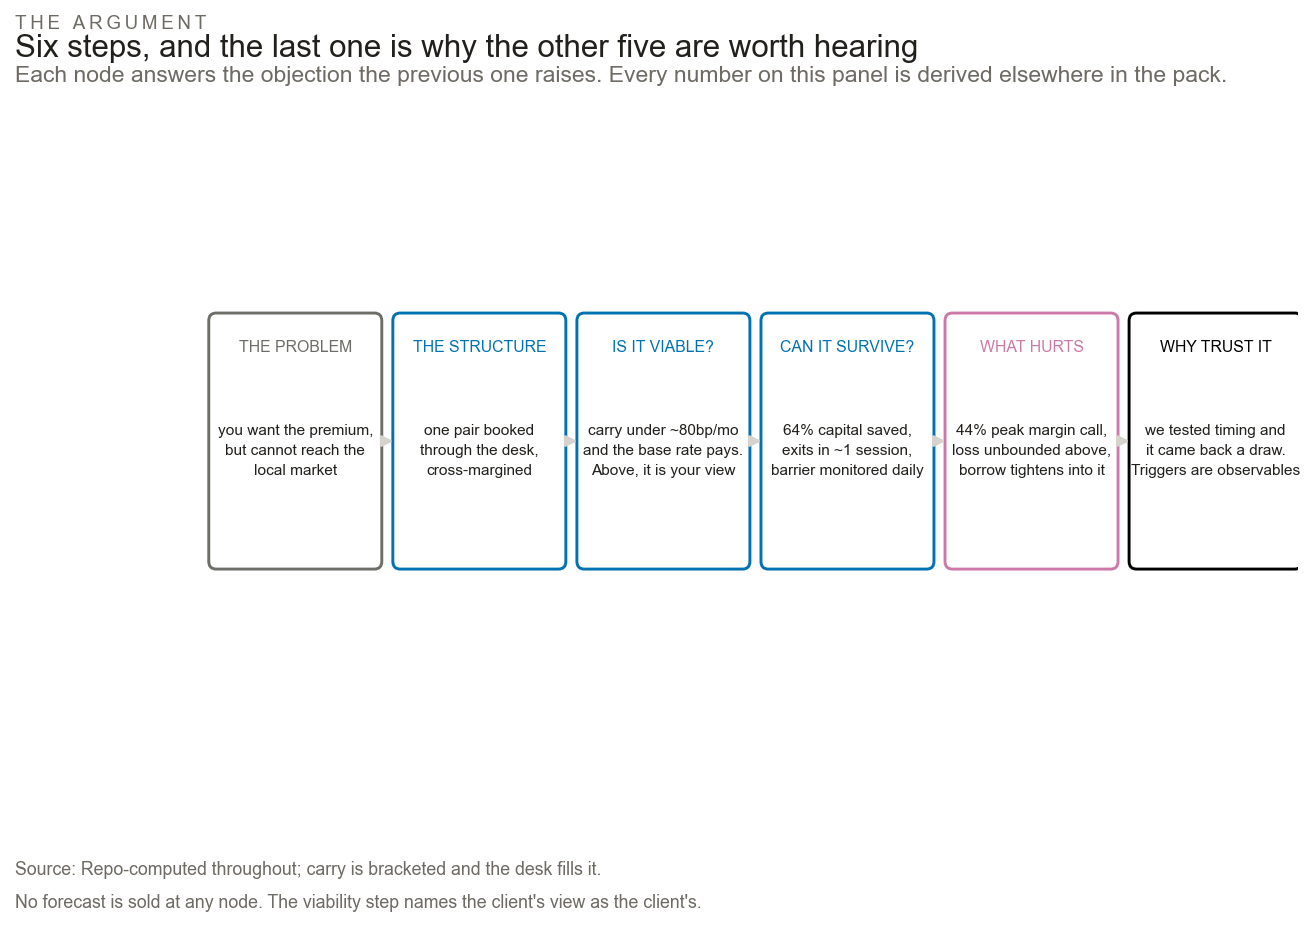

In [2]:
fig, _ = PANELS["P7_the_chain"]()
fig;

**In plain terms**

- Walk it in order: you want the gap, you cannot reach the Korean side, so we hold both legs and
  you hold one position.
- Whether it pays comes down to your funding cost. Whether it survives comes down to margin and
  borrow.
- And we are not selling you timing — we tested that and it did not hold up, which is why the
  triggers are things you can see rather than things we predict.

## 2. Scenario P&L — in return-on-margin, because that is how a book is run

Three paths: compression to the cost floor at the estimated base-rate half-life; static, where
the carry simply bleeds; and the realised widening, applied **additively** from today's level.

The shaded band is the **cost bracket, not a confidence interval.** Four of five carry components
are undocumented, so no path here has a single number.

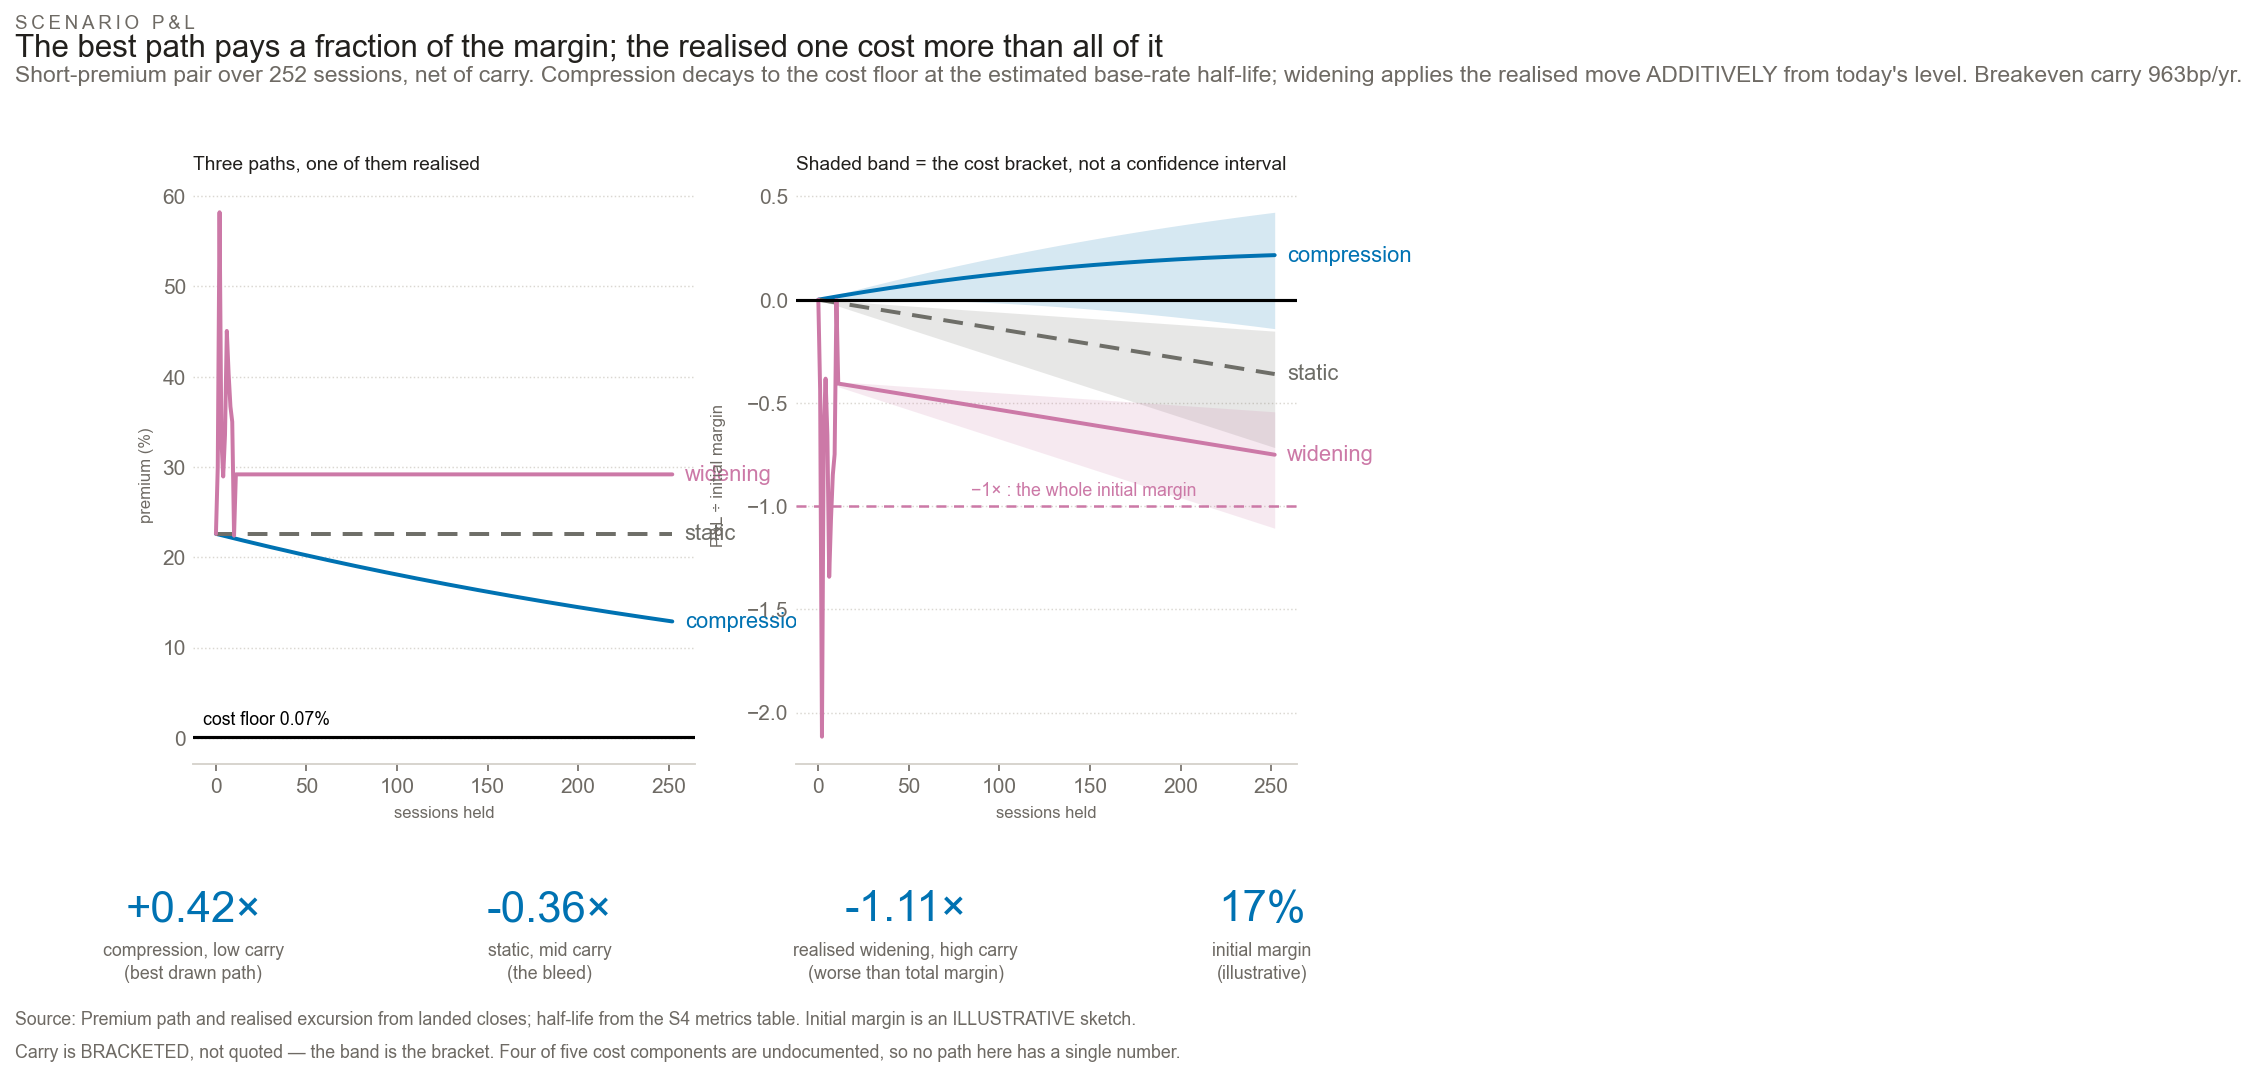

In [3]:
fig, _ = PANELS["P8_scenario_pnl"]()
fig;

**In plain terms**

- Three ways this can go: the gap closes at its normal speed, it sits still while you pay to hold
  it, or it widens the way it actually did in July.
- Best case here makes you about a fifth to two-fifths of the money you had to post. Worst case
  loses more than all of it.
- The shaded band is not uncertainty about the market — it is uncertainty about your own costs,
  and the desk can remove it.

## 3. The hedge menu

**This panel was wrongly deferred once**, on the reasoning that one of its three rows — the
convexity overlay — cannot be priced without a listed-option surface. That dropped two rows that
are presentable, including the FX row, which carries the project's most substantive hedge result:
**a premium position is not FX-neutral even with the local leg fully hedged**, because the premium
is itself a currency-exposed notional.

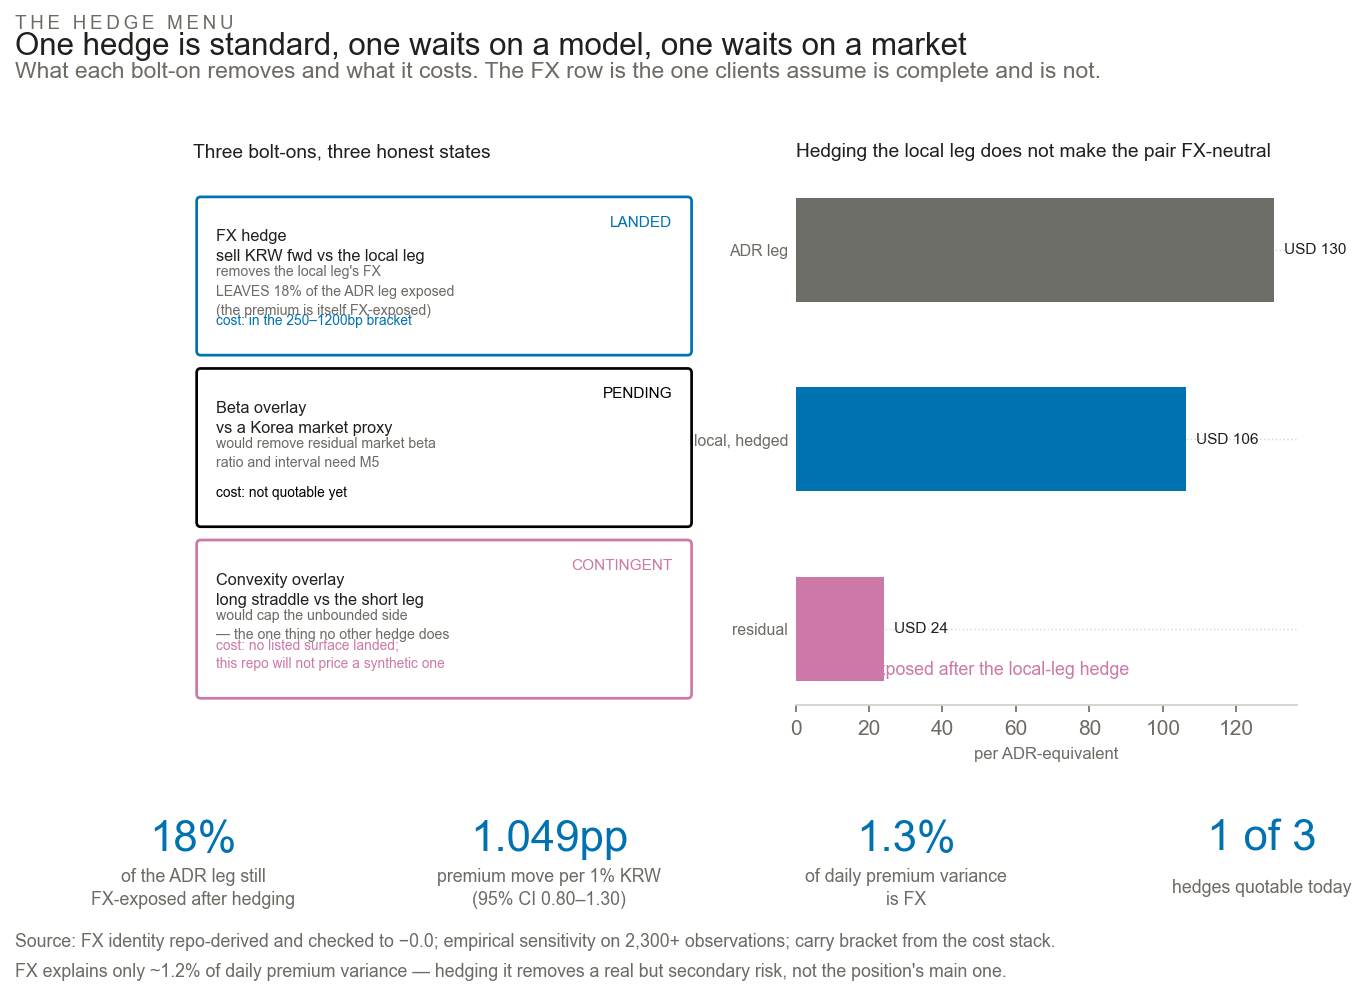

In [4]:
fig, _ = PANELS["P8b_hedge_menu"]()
fig;

**In plain terms**

- Three things you can bolt on. Only one has a price today.
- The currency hedge is standard — but be clear what it does not do: about a quarter of your
  position is still exposed to the won afterwards, because the gap itself is a dollar-versus-won
  number.
- The one that would cap your downside needs listed options that do not exist for this name yet.
  We will not make up a price for it.

## 4. Exit discipline

Since no timing is sold, exits are **rules**, and rules are a tree. Five observables, three
routes, and each monitor points at the route that answers it — recall points at cancellation
because the borrow problem lives on the very leg cancellation extinguishes.

A stop on a gapping spread limits **intent, not loss**: this spread moved 36 points in five
sessions. Sizing bounds loss here; stops express preference.

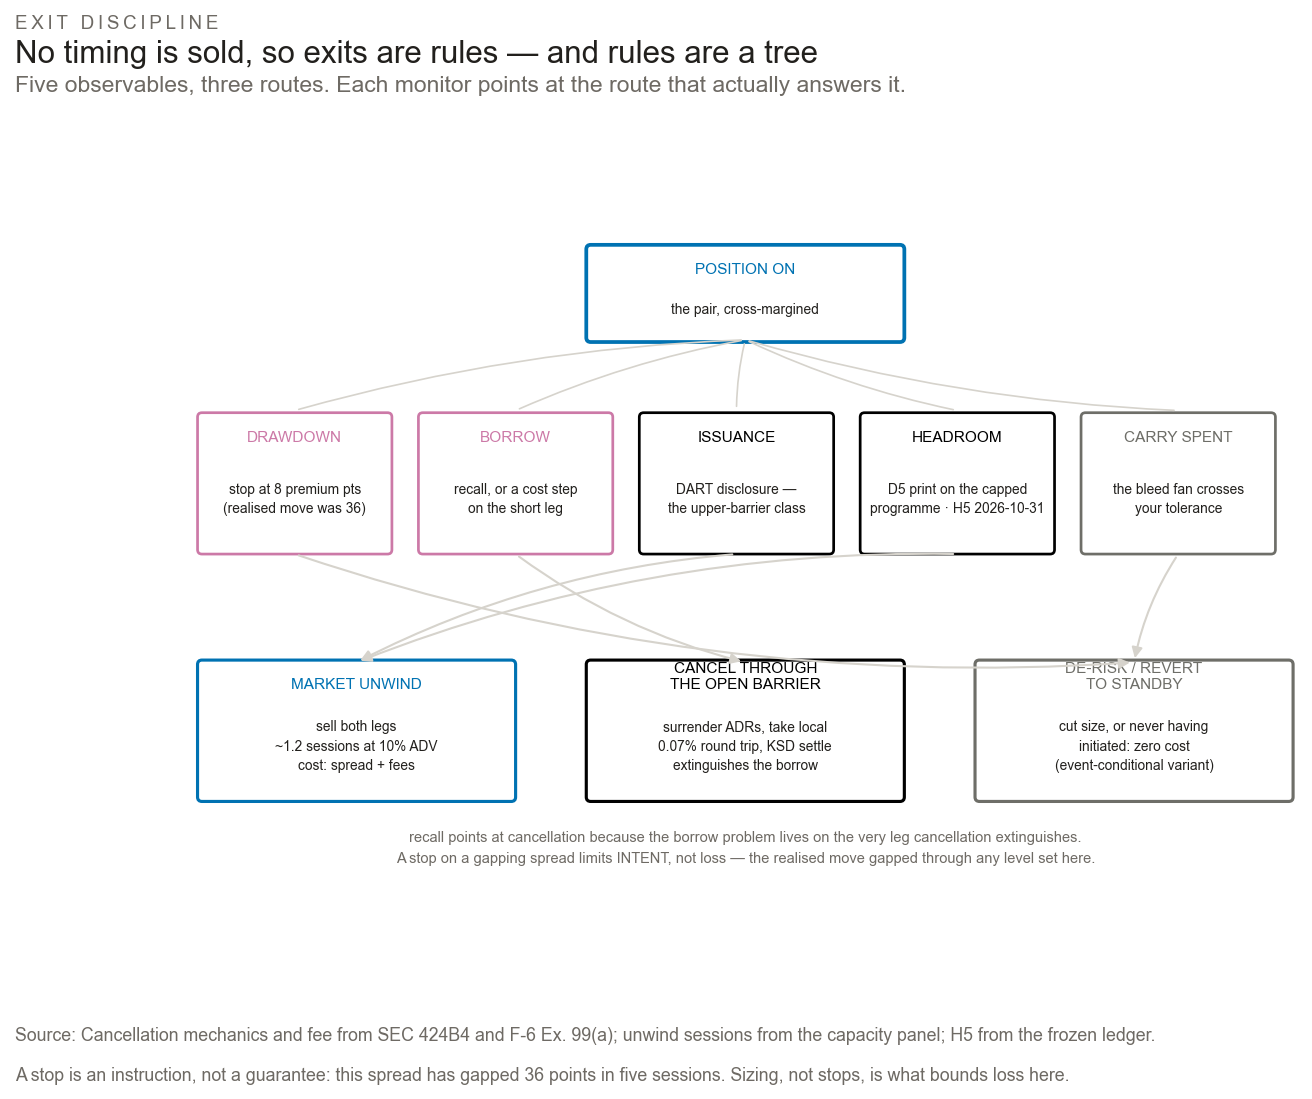

In [5]:
fig, _ = PANELS["P9_exit_discipline"]()
fig;

**In plain terms**

- We are not telling you when to get out, so we agree the rules up front: five things to watch,
  three ways out.
- If the borrow gets pulled, the cleanest exit is handing the US shares back for Korean ones —
  that kills the borrowing problem outright.
- And be honest about stops: this gap jumped 36 points in a week. A stop tells the desk what you
  want, it does not promise you get it.

## 5. The P&L identity — the premium-decay question, settled

A practitioner reading this deck will ask the right question early: *where does the return
come from?* The answer is an identity, and it has exactly two terms.

$$\mathbb{E}[\text{P\&L}] \;=\; \underbrace{-\,\text{financing differential}}_{\text{deterministic}} \;+\; \underbrace{\mathbb{E}[\Delta\pi]}_{\text{zero drift under the structural null}}$$

**Financing is the only deterministic component.** It accrues every day, it is what the desk
prices and earns on, and it is the one number known in advance — subject to four of its five
components still being bracketed assumptions.

**Δπ has no assumed drift, and this repository is the argument for why.** There is no
mechanical convergence force. A premium held open by a consent gate has nothing pulling it
down: cancellation removes ADRs and pushes the premium *up*, and issuance — the only force
that would push it down — requires the Company's consent. That is the barrier framework, and
it cuts against the trade as often as for it. So Δπ is high-variance, catalyst-driven, and
argued for by the **entry level** and the **identifiable channels**, never by decay.

This agrees with the desk's formulation, and it locates the pitch precisely: **financing is
the leg the desk prices; Δπ is the opportunity leg.** Two people who thought they disagreed
were describing the two terms of the same identity.

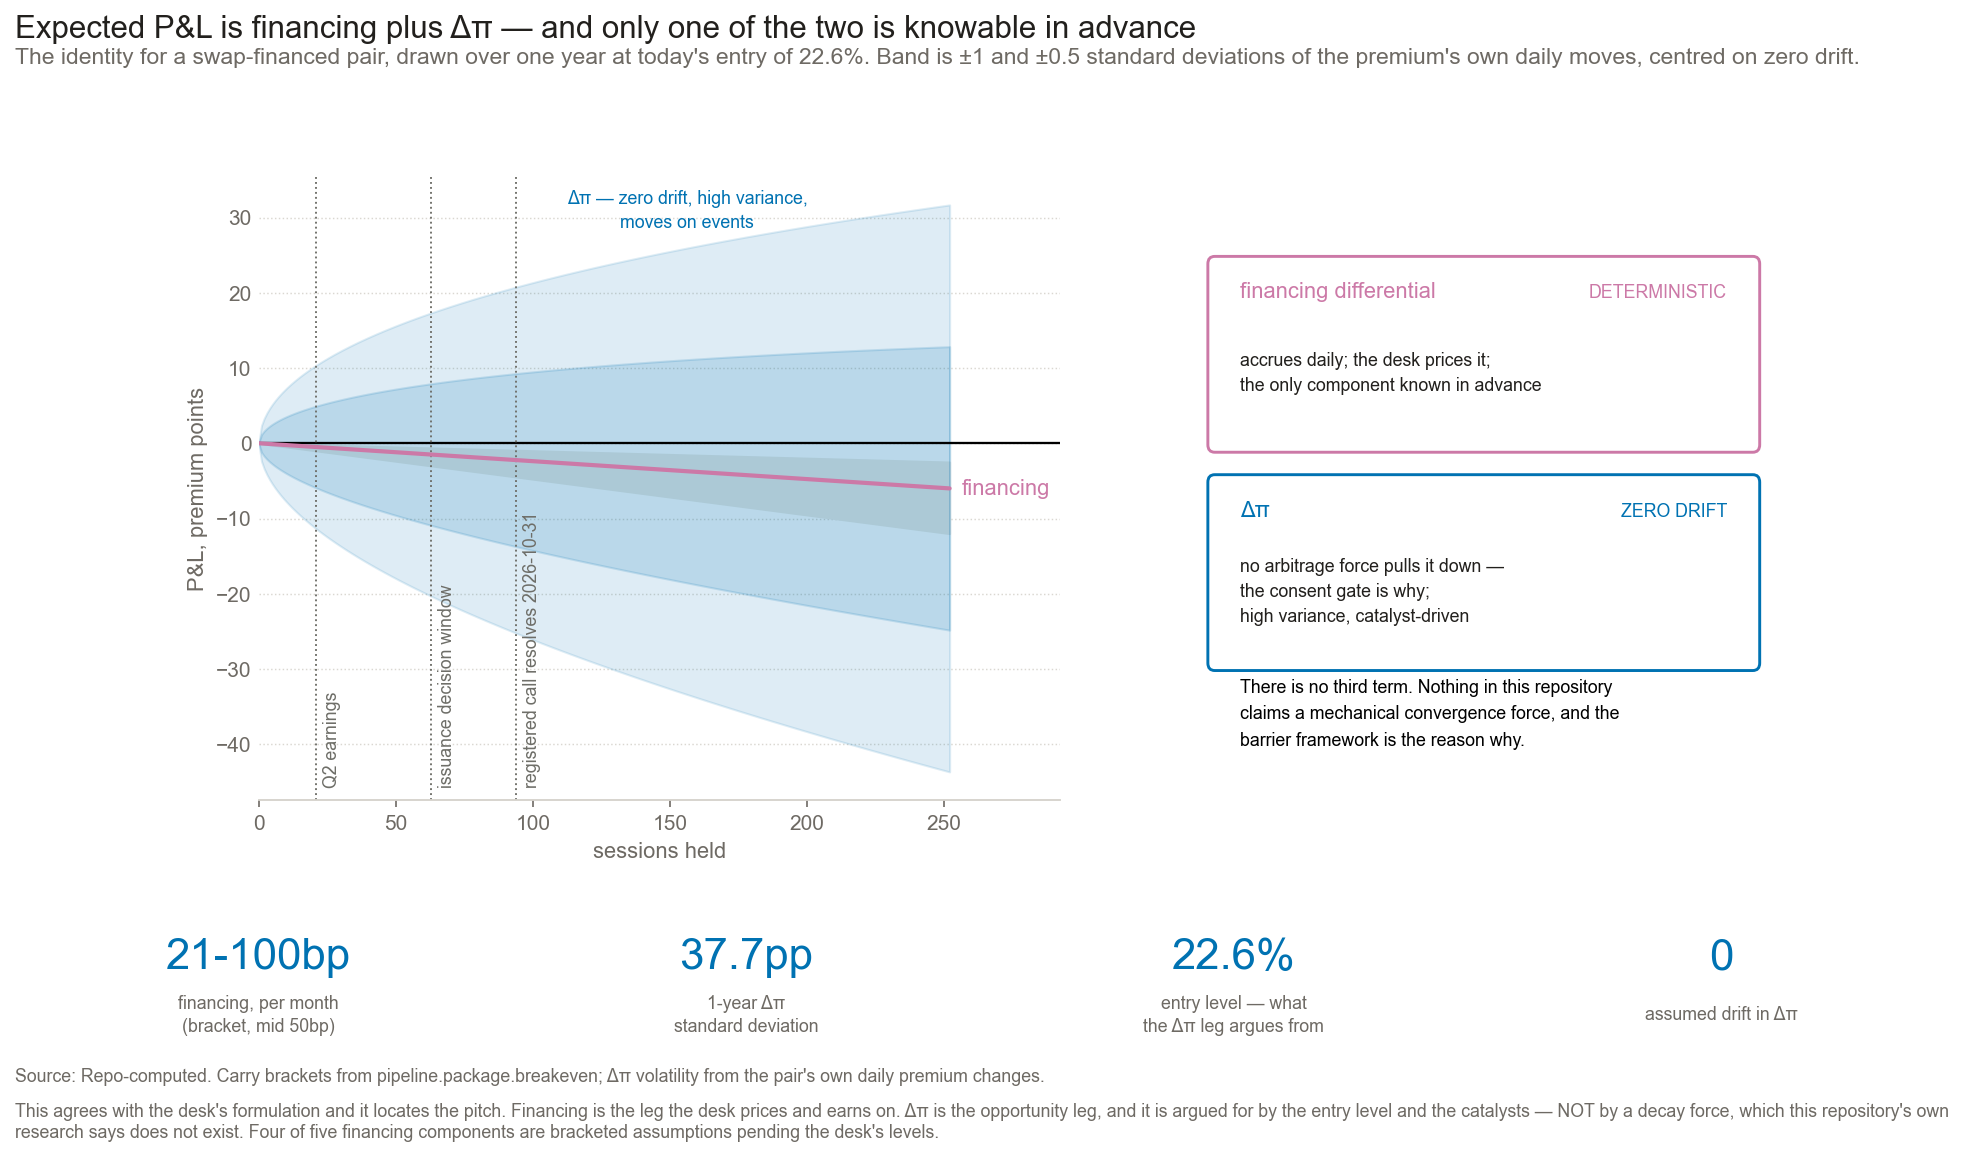

In [6]:
fig, _ = PANELS["S04a_identity"]()
fig;

**In plain terms**

- Two things move this position and only two: the cost of financing it, which is known and ticks
  up every day, and the gap itself, which is not known.
- We do NOT claim the gap has to close. Nothing pulls it down — that is the whole point of the
  research. What we claim is that it starts unusually wide and that there are specific,
  watchable events that could close it.
- So the financing is the part the desk prices, and the gap is the part the entry level and the
  catalysts have to argue for.

## 6. Two registers, one analysis

This repository presents the **research register**: full distributions, the risk analysis,
the nulls, and the results that went against the thesis. The pitch deck derived from it
presents the **opportunity register** appropriate to an internal sales document — which panel
leads, which of three honest paths is featured, and where the qualifier sits.

**Both draw on identical numbers.** Every deck figure is rendered by a builder in this
repository; there is no second set of numbers, and no figure exists in one and not the other
except by ordering. Advocacy is allowed to select and to emphasise. It is not allowed to
invent a number, to quote a cost without its range, or to claim a convergence force the
research disproved — and in `scripts/build_deck_v2.py` those three are assertions that fail
the build, not conventions someone has to remember.

The separation is the point. A sales document that reads like a research paper convinces
nobody, and a research paper that reads like a sales document is worth nothing. The reason
both can exist here is that only the emphasis differs.

---
**Informational only.** Not advice, not a recommendation, not a solicitation. Four of five cost
components are bracketed assumptions; margining is illustrative; the desk quotes real levels.
H5 is a registered call resolving 2026-10-31 and is not resolved here.